In [3]:
import numpy as numpy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('data/stud.csv')

In [6]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
df.shape

(1000, 8)

In [ ]:
df.isna().sum() # Check missing values

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [9]:
df.duplicated().sum() # Check duplicates

np.int64(0)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [12]:
df.nunique() # Ceck number of values of each column

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [14]:
df.describe() # Check statistics of dataset

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [23]:
print("gender classes: ", df['gender'].unique())
print("_______________________")

print("lunch classes: ", df['lunch'].unique())
print("_______________________")

print("race/ethnicity classes: ", df['race_ethnicity'].unique())
print("_______________________")

print("parents level of education classes: ", df['parental_level_of_education'].unique())
print("_______________________")

print("test preparation classes: ", df['test_preparation_course'].unique())
print("_______________________")

gender classes:  <StringArray>
['female', 'male']
Length: 2, dtype: str
_______________________
lunch classes:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
_______________________
race/ethnicity classes:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
_______________________
parents level of education classes:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
_______________________
test preparation classes:  <StringArray>
['none', 'completed']
Length: 2, dtype: str
_______________________


In [39]:
# Check categorical columns in dataset
categorical_cols = [col for col in df.columns if df[col].dtype in ('O', 'string')]
print("Categorical featuers: ",categorical_cols)

# Check numerical columns in dataset
numerical_cols = [col for col in df.columns if df[col].dtype not in ('O', 'string')]
print("Numerical features: ",numerical_cols)

Categorical featuers:  ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']
Numerical features:  ['math_score', 'reading_score', 'writing_score']


In [41]:
# Add new features to dataset (Average score and Total score)
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total_score'] / 3

In [43]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [51]:
reading_fullMark =  df[df['reading_score'] == 100]['average'].count()
writing_fullMark =  df[df['writing_score'] == 100]['average'].count()
math_fullMark =  df[df['math_score'] == 100]['average'].count()

print(f"Number of studnets with full mark in math: {math_fullMark}")
print(f"Number of studnets with full mark in reading: {reading_fullMark}")
print(f"Number of studnets with full mark in writing: {writing_fullMark}")

Number of studnets with full mark in math: 7
Number of studnets with full mark in reading: 17
Number of studnets with full mark in writing: 14


In [ ]:
# check number of students who succeded in math and failed in reading
condition = df[(df["reading_score"] < 50) & (df['math_score'] > 50)]['average'].count()
print(condition)

27


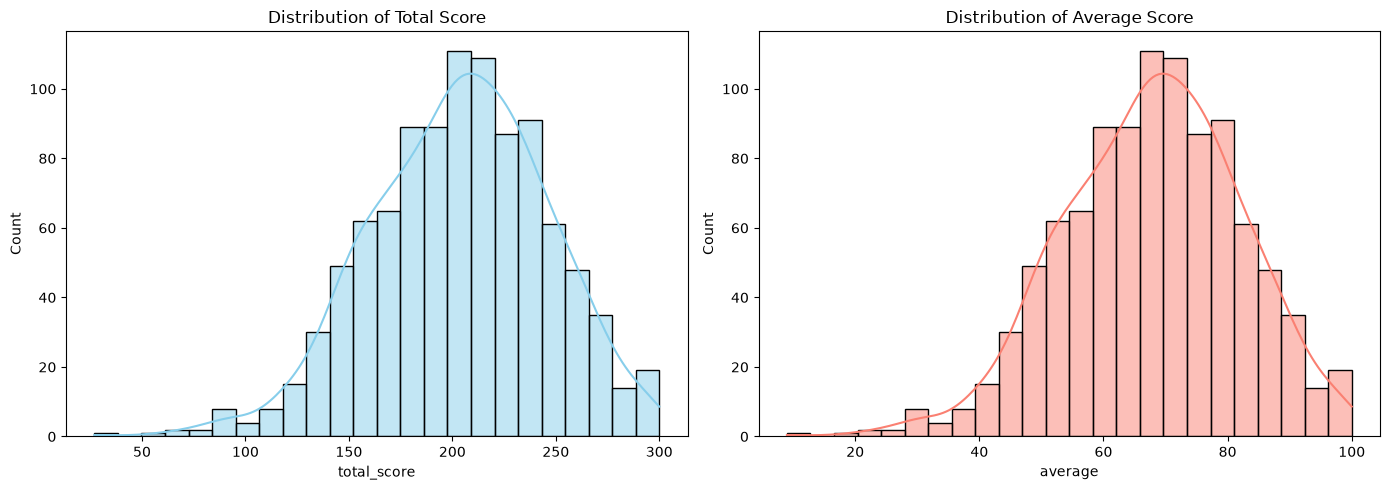

In [65]:
# 1. Distribution of total score and average score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='total_score', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Total Score')

sns.histplot(data=df, x='average', kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Average Score')

plt.tight_layout()
plt.show()

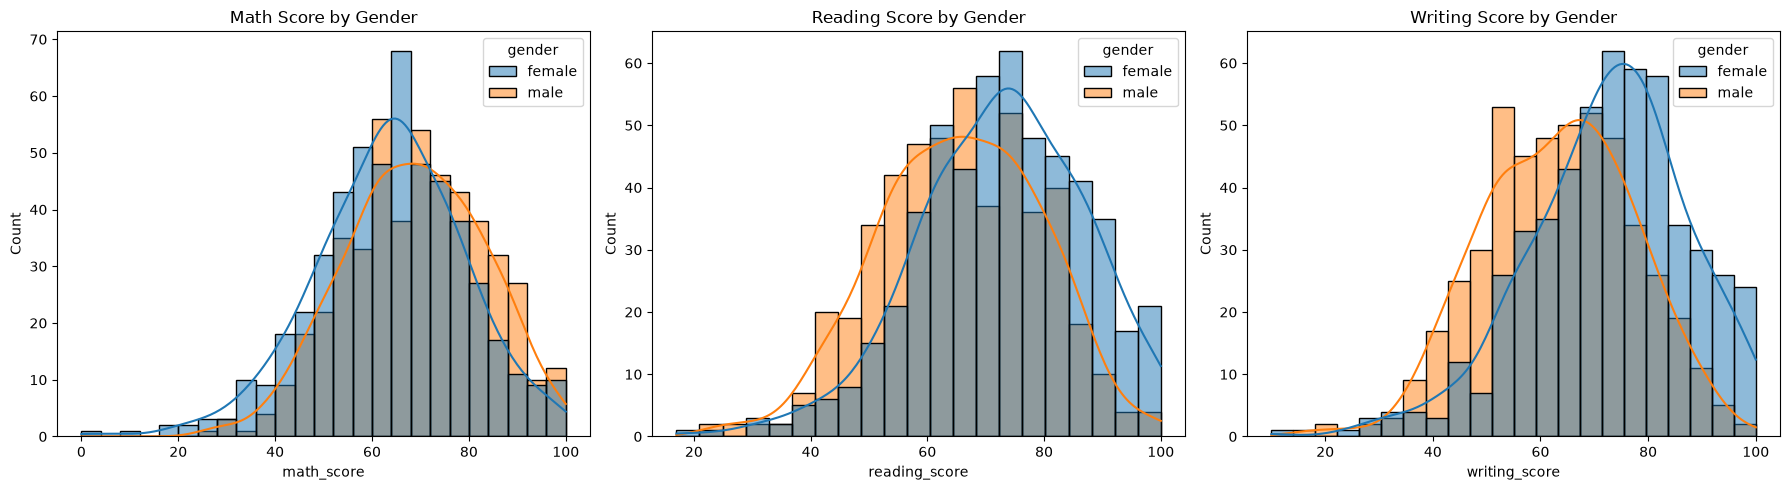

In [66]:
# 2. Score distribution by gender
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='math_score', hue='gender', kde=True, ax=axes[0])
axes[0].set_title('Math Score by Gender')

sns.histplot(data=df, x='reading_score', hue='gender', kde=True, ax=axes[1])
axes[1].set_title('Reading Score by Gender')

sns.histplot(data=df, x='writing_score', hue='gender', kde=True, ax=axes[2])
axes[2].set_title('Writing Score by Gender')

plt.tight_layout()
plt.show()

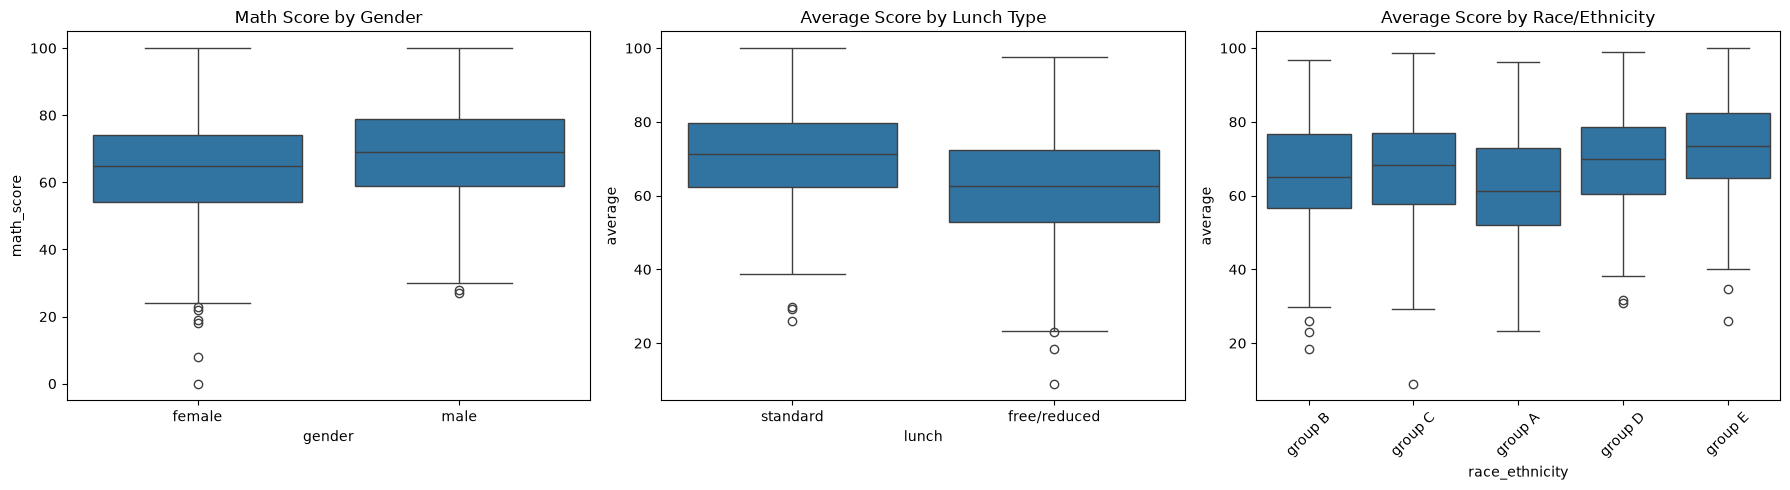

In [67]:
# 3. Boxplots — spot outliers and compare spread across scores
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='gender', y='math_score', ax=axes[0])
axes[0].set_title('Math Score by Gender')

sns.boxplot(data=df, x='lunch', y='average', ax=axes[1])
axes[1].set_title('Average Score by Lunch Type')

sns.boxplot(data=df, x='race_ethnicity', y='average', ax=axes[2])
axes[2].set_title('Average Score by Race/Ethnicity')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()